<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>DBSCAN From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Turn the DBSCAN idea into actual code using simple functions</li>
<li>Find neighbors, grow clusters, and mark noise</li>
<li>Run it on the two moons data and see the clusters</li>
<li>Check the result against sklearn</li>
</ol>
In the last notebook i understood the idea, dense areas are clusters and lonely points are noise. Now i will write it from scratch. No class this time, just a couple of functions. I only use sklearn at the end to compare.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The algorithm in words</b>
</h2>
<div style="font-family:'Times New Roman';">
Here is the plan before coding.
<ol>
<li>Go through every point that has not been visited yet.</li>
<li>Find all its neighbors inside eps.</li>
<li>If it has fewer than min_pts neighbors, mark it as noise for now (it might still become a border point later).</li>
<li>If it has enough neighbors, start a new cluster and keep pulling in all the neighbors, and the neighbors of any neighbor that is also a core point.</li>
<li>Repeat until every point is either in a cluster or marked noise.</li>
</ol>
</div>

In [2]:
np.random.seed(42)
X, _ = make_moons(n_samples=300, noise=0.06, random_state=42)
print("Data shape:", X.shape)

Data shape: (300, 2)


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Function 1 finding the neighbors</b>
</h2>
<div style="font-family:'Times New Roman';">
First a small function that, given a point, returns all the points that are within eps distance of it. This is the building block for everything else.
</div>

In [3]:
def region_query(X, idx, eps):
    # return the indices of all points within eps distance of point idx
    point = X[idx]
    neighbors = []
    for i in range(len(X)):
        distance = np.sqrt(np.sum((point - X[i]) ** 2))
        if distance <= eps:
            neighbors.append(i)
    return neighbors

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Function 2 the main dbscan loop</b>
</h2>
<div style="font-family:'Times New Roman';">
Now the main function. I use a label array where 0 means not visited yet, -1 means noise, and any positive number is a cluster id. I grow each cluster using a simple queue.
</div>

In [4]:
def dbscan(X, eps, min_pts):
    n = len(X)
    labels = np.zeros(n, dtype=int)   # 0 means not visited yet
    cluster_id = 0

    for idx in range(n):
        # skip points we already handled
        if labels[idx] != 0:
            continue

        neighbors = region_query(X, idx, eps)

        # not enough neighbors, call it noise for now
        if len(neighbors) < min_pts:
            labels[idx] = -1
            continue

        # otherwise start a brand new cluster
        cluster_id += 1
        labels[idx] = cluster_id

        # grow the cluster using a queue of points to check
        queue = list(neighbors)
        i = 0
        while i < len(queue):
            j = queue[i]
            i += 1

            # a point earlier marked noise is actually a border point of this cluster
            if labels[j] == -1:
                labels[j] = cluster_id

            # already assigned to some cluster, leave it
            if labels[j] != 0:
                continue

            # add this unvisited point to the cluster
            labels[j] = cluster_id

            # if it is also a core point, its neighbors join the queue too
            j_neighbors = region_query(X, j, eps)
            if len(j_neighbors) >= min_pts:
                queue.extend(j_neighbors)

    return labels

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Running it on the moons</b>
</h2>
<div style="font-family:'Times New Roman';">
Lets run our DBSCAN with eps 0.2 and min_pts 5.
</div>

In [5]:
eps = 0.2
min_pts = 5

labels = dbscan(X, eps, min_pts)

n_clusters = len(set(labels) - {-1})
n_noise = np.sum(labels == -1)

print("Number of clusters found:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters found:

 2
Number of noise points: 0


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Plotting the clusters</b>
</h2>
<div style="font-family:'Times New Roman';">
Now lets see what it found. The noise points are drawn as black crosses.
</div>

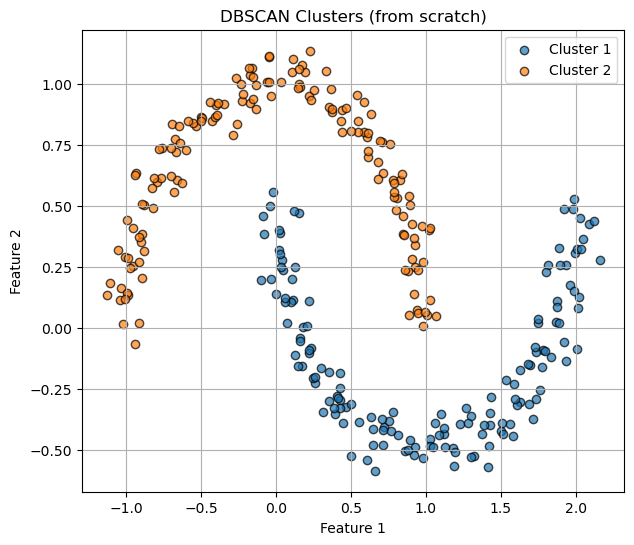

In [6]:
plt.figure(figsize=(7, 6))

for lab in sorted(set(labels)):
    mask = labels == lab
    if lab == -1:
        plt.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', label='Noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], edgecolors='k', alpha=0.7, label=f'Cluster {lab}')

plt.title("DBSCAN Clusters (from scratch)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Checking against sklearn</b>
</h2>
<div style="font-family:'Times New Roman';">
Lets confirm our version agrees with sklearn. The actual cluster numbers might be swapped (cluster 1 and 2 could be named the other way around) but the grouping should be the same, so the number of clusters and the number of noise points should match.
</div>

In [7]:
from sklearn.cluster import DBSCAN

sk = DBSCAN(eps=eps, min_samples=min_pts)
sk_labels = sk.fit_predict(X)

print("Our clusters:    ", len(set(labels) - {-1}), "| our noise:", np.sum(labels == -1))
print("sklearn clusters:", len(set(sk_labels) - {-1}), "| sklearn noise:", np.sum(sk_labels == -1))

Our clusters:     2 | our noise: 0
sklearn clusters: 2 | sklearn noise: 0


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Wrote DBSCAN from scratch with two small functions, one to find neighbors and one for the main loop</li>
<li>Used a label array, 0 not visited, -1 noise, positive numbers for the clusters</li>
<li>Grew each cluster with a queue so it can follow the curvy moon shapes</li>
<li>It found the 2 moons correctly and marked the lonely points as noise</li>
<li>Our result matched sklearn on the number of clusters and noise points</li>
</ul>
Next i will put DBSCAN and K-Means side by side to clearly see where K-Means breaks and DBSCAN wins.
</div>